# 01 — Dataset Exploration

Loads `antenna_dataset.mat` (PixelAnt format) and explores the raw data.

| Variable | Shape | Description |
|----------|-------|-------------|
| `XTrain1` | `(N, 1, 12, 12)` | Binary pixel grids — 0 = no metal, 1 = metal |
| `YTrain` | `(81, N)` | S₁₁ return-loss magnitude (dB) at 81 frequency points |

The dataset was generated by the [PixelAnt](https://github.com/udaykdk/pixelant) project using MATLAB's Antenna Toolbox (Method-of-Moments solver) on a 12×12 pixel microstrip grid over an FR4 substrate.

In [6]:
import os
from pathlib import Path

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

NB_DIR   = Path(os.path.abspath(''))
MAT_FILE = NB_DIR / 'antenna_dataset.mat'

print(f'Loading: {MAT_FILE}')
mat = scipy.io.loadmat(MAT_FILE)

X_raw = mat['XTrain1']   # (N, 1, 12, 12) uint8
Y_raw = mat['YTrain']    # (81, N)        float64

print(f'XTrain1 : shape={X_raw.shape}, dtype={X_raw.dtype}')
print(f'YTrain  : shape={Y_raw.shape}, dtype={Y_raw.dtype}')

N_SAMPLES = X_raw.shape[0]
GRID_SIZE = 12
N_FREQ    = Y_raw.shape[0]
print(f'\n{N_SAMPLES:,} samples | {GRID_SIZE}×{GRID_SIZE} pixel grid | {N_FREQ} frequency bins')

Loading: /home/irman/Gelochip/notebooks/pixelatedRF/antenna_dataset.mat
XTrain1 : shape=(677479, 1, 12, 12), dtype=uint8
YTrain  : shape=(81, 677479), dtype=float64

677,479 samples | 12×12 pixel grid | 81 frequency bins


In [7]:
# ── Reshape into canonical (N, 144) and (N, 81) tensors ──────────────────────
X = X_raw.reshape(N_SAMPLES, GRID_SIZE, GRID_SIZE).astype(np.float32)  # (N, 12, 12)
Y = Y_raw.T.astype(np.float32)                                          # (N, 81)

print(f'X (layouts)      : {X.shape}  values in {{{X.min():.0f}, {X.max():.0f}}}')
print(f'Y (S11 in dB)    : {Y.shape}  range [{Y.min():.1f}, {Y.max():.1f}] dB')

# Metal density per layout
density = X.mean(axis=(1, 2))
print(f'\nMetal density  : mean={density.mean():.3f}  std={density.std():.3f}  '
      f'min={density.min():.3f}  max={density.max():.3f}')

X (layouts)      : (677479, 12, 12)  values in {0, 1}
Y (S11 in dB)    : (677479, 81)  range [-64.3, 4.2] dB

Metal density  : mean=0.672  std=0.039  min=0.486  max=0.854


In [8]:
# ── Frequency axis (PixelAnt: 1–10 GHz, 81 uniformly-spaced points) ──────────
# The .mat file does not store the frequency axis; reconstruct from PixelAnt defaults
F_MIN_GHZ = 1.0
F_MAX_GHZ = 10.0
freqs = np.linspace(F_MIN_GHZ, F_MAX_GHZ, N_FREQ)   # GHz

print(f'Frequency axis: {freqs[0]:.2f} – {freqs[-1]:.2f} GHz  ({N_FREQ} points)')

Frequency axis: 1.00 – 10.00 GHz  (81 points)


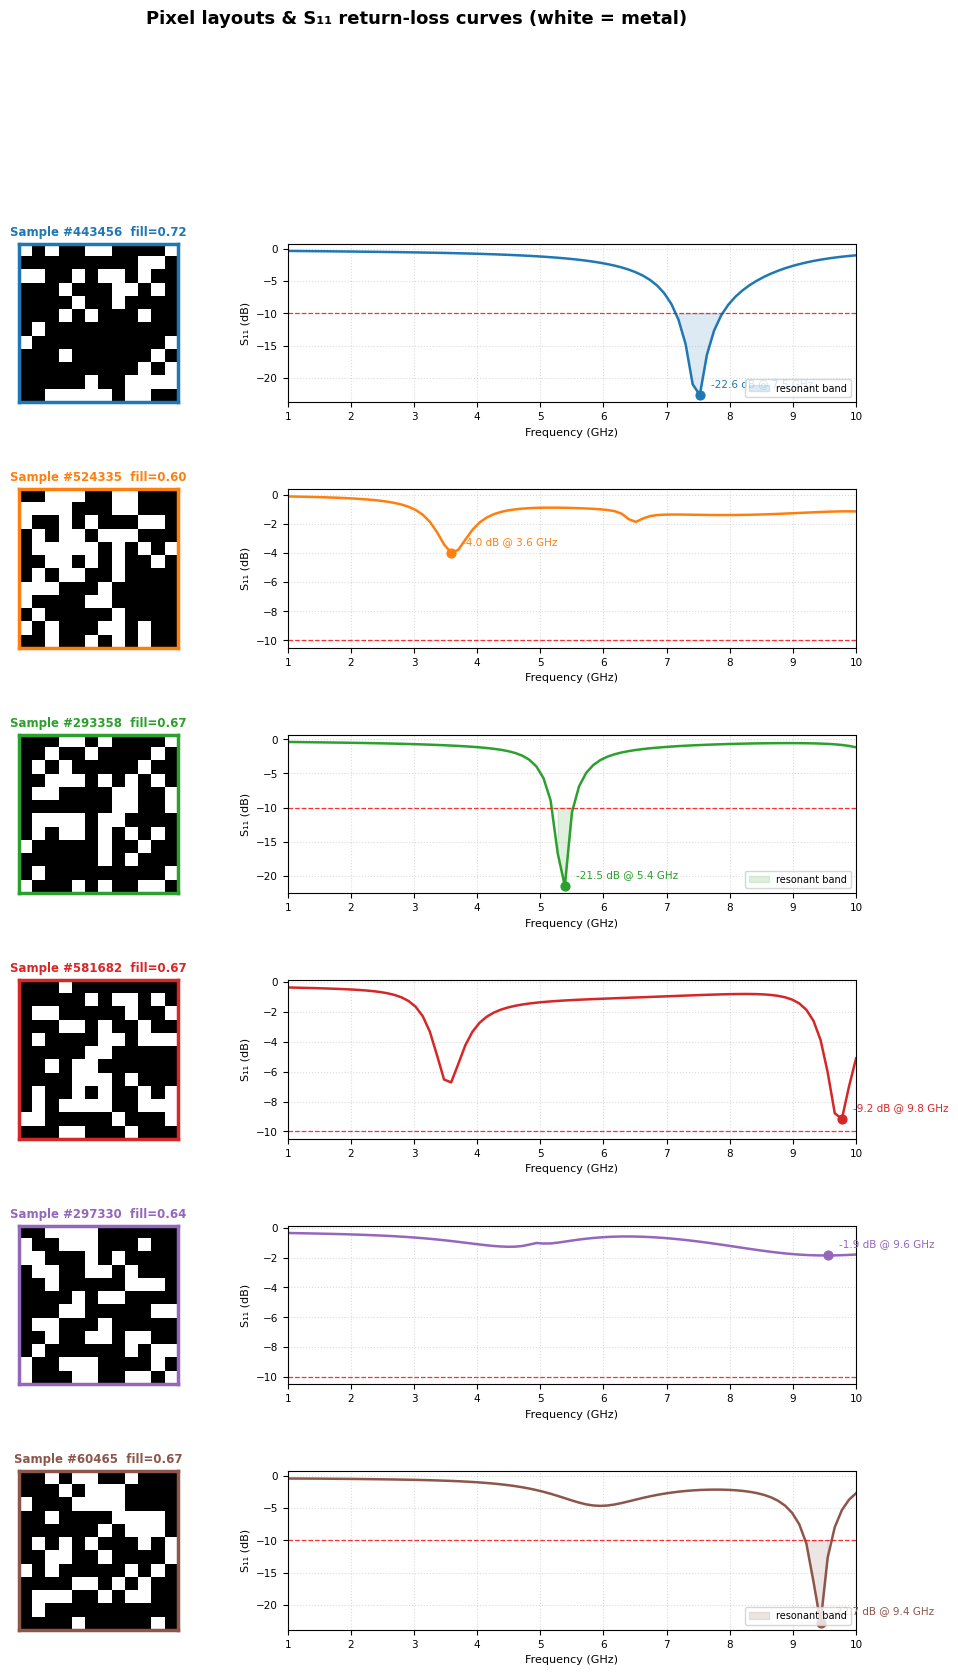

Saved → fig_layout_s11_pairs.png


In [9]:
# ── Pixel layout + S₁₁ curve side-by-side for 6 random samples ───────────────
N_PAIRS = 6
rng = np.random.default_rng(42)
idx = rng.choice(N_SAMPLES, size=N_PAIRS, replace=False)

fig = plt.figure(figsize=(11, 3.0 * N_PAIRS))
fig.suptitle('Pixel layouts & S₁₁ return-loss curves (white = metal)',
             fontsize=13, fontweight='bold', y=1.01)

gs = fig.add_gridspec(N_PAIRS, 2, width_ratios=[1, 3], hspace=0.55, wspace=0.25)

colors = plt.cm.tab10.colors

for row, i in enumerate(idx):
    color = colors[row % len(colors)]

    # ── Left: pixel grid ──────────────────────────────────────────────────────
    ax_px = fig.add_subplot(gs[row, 0])
    ax_px.imshow(X[i], cmap='binary', vmin=0, vmax=1, interpolation='nearest')
    for spine in ax_px.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
    ax_px.set_title(f'Sample #{i}  fill={X[i].mean():.2f}', fontsize=8.5,
                    color=color, fontweight='bold')
    ax_px.set_xticks([])
    ax_px.set_yticks([])

    # ── Right: S₁₁ curve ─────────────────────────────────────────────────────
    ax_s = fig.add_subplot(gs[row, 1])
    ax_s.plot(freqs, Y[i], color=color, linewidth=1.8)
    ax_s.axhline(-10, color='red', linestyle='--', linewidth=0.9, alpha=0.8)
    ax_s.fill_between(freqs, Y[i], -10,
                      where=(Y[i] < -10), alpha=0.15, color=color,
                      label='resonant band')
    # Mark resonance minimum
    min_idx = np.argmin(Y[i])
    ax_s.scatter(freqs[min_idx], Y[i][min_idx], color=color, s=40, zorder=5)
    ax_s.annotate(f'{Y[i][min_idx]:.1f} dB @ {freqs[min_idx]:.1f} GHz',
                  xy=(freqs[min_idx], Y[i][min_idx]),
                  xytext=(8, 6), textcoords='offset points',
                  fontsize=7.5, color=color)
    ax_s.set_xlim(freqs[0], freqs[-1])
    ax_s.set_xlabel('Frequency (GHz)', fontsize=8)
    ax_s.set_ylabel('S₁₁ (dB)',        fontsize=8)
    ax_s.tick_params(labelsize=7.5)
    ax_s.grid(True, linestyle=':', alpha=0.45)
    if (Y[i] < -10).any():
        ax_s.legend(fontsize=7, loc='lower right')

plt.savefig(NB_DIR / 'fig_layout_s11_pairs.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → fig_layout_s11_pairs.png')

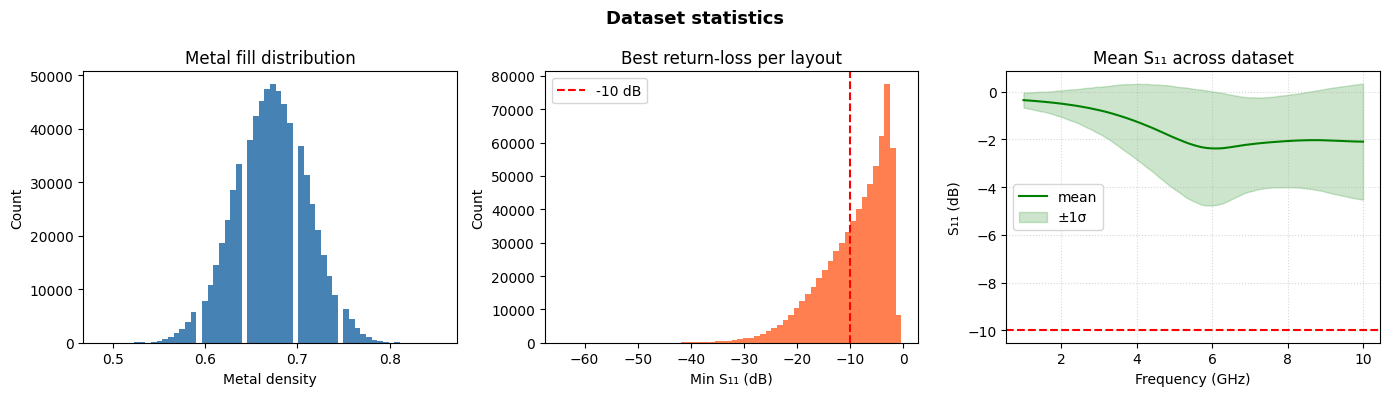

Layouts with S11 < -10 dB: 249,148 / 677,479  (36.8%)


In [10]:
# ── Dataset statistics ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Dataset statistics', fontsize=13, fontweight='bold')

# Metal density histogram
axes[0].hist(density, bins=60, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Metal density')
axes[0].set_ylabel('Count')
axes[0].set_title('Metal fill distribution')

# S11 minimum per sample
s11_min = Y.min(axis=1)
axes[1].hist(s11_min, bins=60, color='coral', edgecolor='none')
axes[1].axvline(-10, color='red', linestyle='--', label='-10 dB')
axes[1].set_xlabel('Min S₁₁ (dB)')
axes[1].set_ylabel('Count')
axes[1].set_title('Best return-loss per layout')
axes[1].legend()

# Mean S11 over frequency
axes[2].plot(freqs, Y.mean(axis=0), color='green', label='mean')
axes[2].fill_between(freqs, Y.mean(axis=0) - Y.std(axis=0),
                     Y.mean(axis=0) + Y.std(axis=0),
                     alpha=0.2, color='green', label='±1σ')
axes[2].axhline(-10, color='red', linestyle='--')
axes[2].set_xlabel('Frequency (GHz)')
axes[2].set_ylabel('S₁₁ (dB)')
axes[2].set_title('Mean S₁₁ across dataset')
axes[2].legend()
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(NB_DIR / 'fig_statistics.png', dpi=120, bbox_inches='tight')
plt.show()

resonant = (s11_min < -10).sum()
print(f'Layouts with S11 < -10 dB: {resonant:,} / {N_SAMPLES:,}  ({100*resonant/N_SAMPLES:.1f}%)')

In [11]:
# ── Train / validation / test split and save as numpy ────────────────────────
from sklearn.model_selection import train_test_split

idx_all = np.arange(N_SAMPLES)
idx_train, idx_tmp = train_test_split(idx_all, test_size=0.2, random_state=42)
idx_val, idx_test  = train_test_split(idx_tmp, test_size=0.5, random_state=42)

print(f'Train : {len(idx_train):>7,}')
print(f'Val   : {len(idx_val):>7,}')
print(f'Test  : {len(idx_test):>7,}')

SPLIT_FILE = NB_DIR / 'data_split.npz'
np.savez(SPLIT_FILE,
         X_train=X[idx_train], Y_train=Y[idx_train],
         X_val=X[idx_val],     Y_val=Y[idx_val],
         X_test=X[idx_test],   Y_test=Y[idx_test],
         freqs=freqs)
print(f'\nSaved splits to {SPLIT_FILE}')

Train : 541,983
Val   :  67,748
Test  :  67,748

Saved splits to /home/irman/Gelochip/notebooks/pixelatedRF/data_split.npz
